<a href="https://colab.research.google.com/github/nijatbayramoov/Ailines_flights_project/blob/main/Airlines_flights_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




#1.Datasetin Yoxlanması və Əsas Statistikası



In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Dataset/airlines_flights_data.csv", index_col='index')

In [ ]:
df.head(2)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
index,,,,,,,,,,,
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 27.5+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Datasetdə hansı aviaşirkətlər var və onların tezlikləri nə qədərdir?

In [ ]:
df['airline'].value_counts().sort_values(ascending=False).reset_index()



,airline,count
0,Vistara,127859
1,Air_India,80892
2,Indigo,43120
3,GO_FIRST,23173
4,AirAsia,16098
5,SpiceJet,9011


In [ ]:
#Gediş vaxtı və Gəliş vaxtını təmsil edən Bar Qrafikləri göstərin. (bu suali tam basa dusmedim)

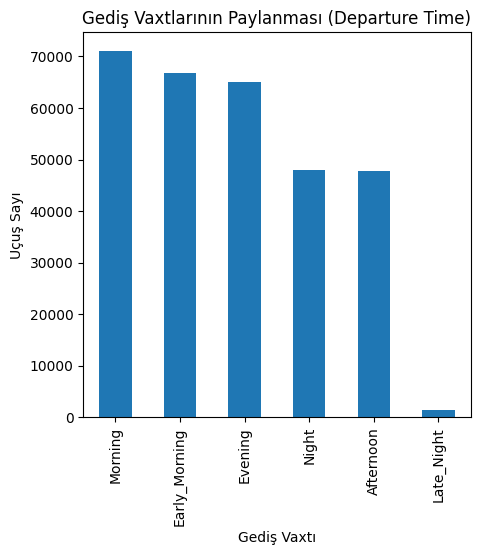

In [ ]:
plt.figure(figsize=(5, 5))
df['departure_time'].value_counts().plot(kind='bar')
plt.title('Gediş Vaxtlarının Paylanması (Departure Time)')
plt.xlabel('Gediş Vaxtı')
plt.ylabel('Uçuş Sayı')
plt.show()

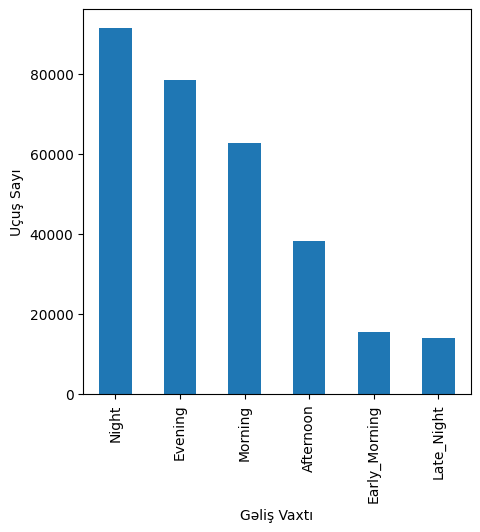

In [ ]:
plt.figure(figsize=(5, 5))
df['arrival_time'].value_counts().plot(kind='bar')
plt.xlabel('Gəliş Vaxtı')
plt.ylabel('Uçuş Sayı')
plt.show()

In [ ]:
#Mənbə Şəhəri və Təyinat Şəhəri təmsil edən Bar Qrafikləri göstərin.

<Axes: title={'center': 'Source City vs Destination City'}>

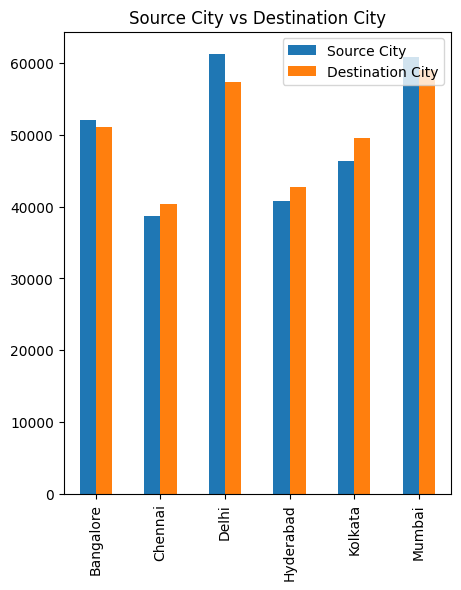

In [ ]:
import pandas as pd

city_df = pd.DataFrame({
    'Source City': df['source_city'].value_counts(),
    'Destination City': df['destination_city'].value_counts()
})

city_df.plot(
    kind='bar',
    figsize=(5,6),
    title='Source City vs Destination City'
)

In [ ]:
#Qiymət aviaşirkətlərə görə dəyişirmi?

In [ ]:
df2=df.groupby('airline')['price'].agg(['mean','median']).sort_values('mean',ascending=False).round(2).reset_index()
df2.rename(columns={'airline':'Airline','price':'Price'})

,Airline,mean,median
0,Vistara,30396.54,15543.0
1,Air_India,23507.02,11520.0
2,SpiceJet,6179.28,5654.0
3,GO_FIRST,5652.01,5336.0
4,Indigo,5324.22,4453.0
5,AirAsia,4091.07,3276.0


<Figure size 1000x500 with 0 Axes>

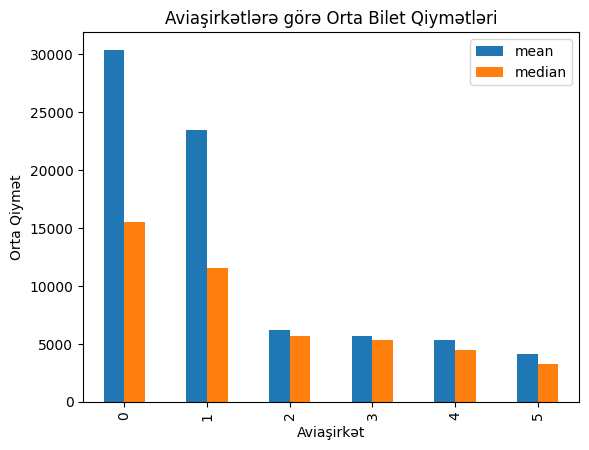

In [ ]:
plt.figure(figsize=(10, 5))
df2.plot(kind='bar')
plt.title('Aviaşirkətlərə görə Orta Bilet Qiymətləri')
plt.xlabel('Aviaşirkət')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Bilet qiyməti gediş vaxtı və gəliş vaxtına əsasən dəyişirmi?

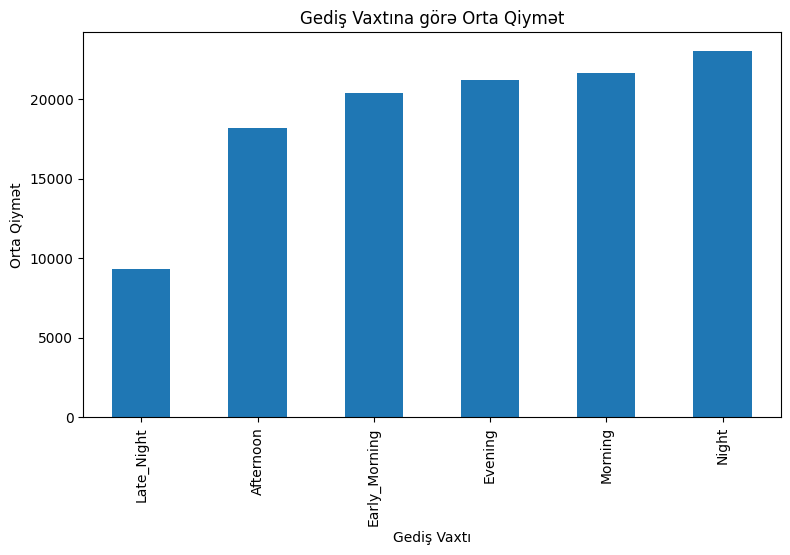

In [ ]:
plt.figure(figsize=(9, 5))
df.groupby('departure_time')['price'].mean().sort_values().plot(kind='bar')
plt.title('Gediş Vaxtına görə Orta Qiymət')
plt.xlabel('Gediş Vaxtı')
plt.ylabel('Orta Qiymət')
plt.show()

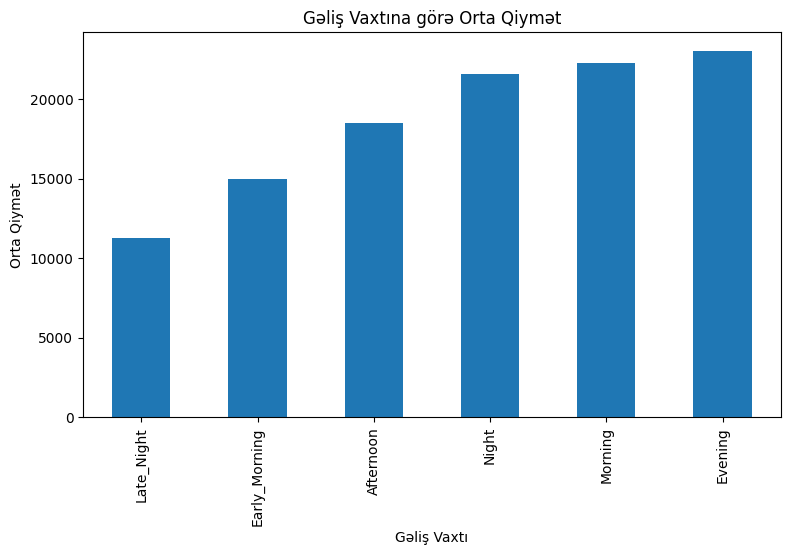

In [ ]:
plt.figure(figsize=(9, 5))
df.groupby('arrival_time')['price'].mean().sort_values().plot(kind='bar')
plt.title('Gəliş Vaxtına görə Orta Qiymət')
plt.xlabel('Gəliş Vaxtı')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Qiymət mənbə və təyinatın dəyişməsi ilə necə dəyişir?

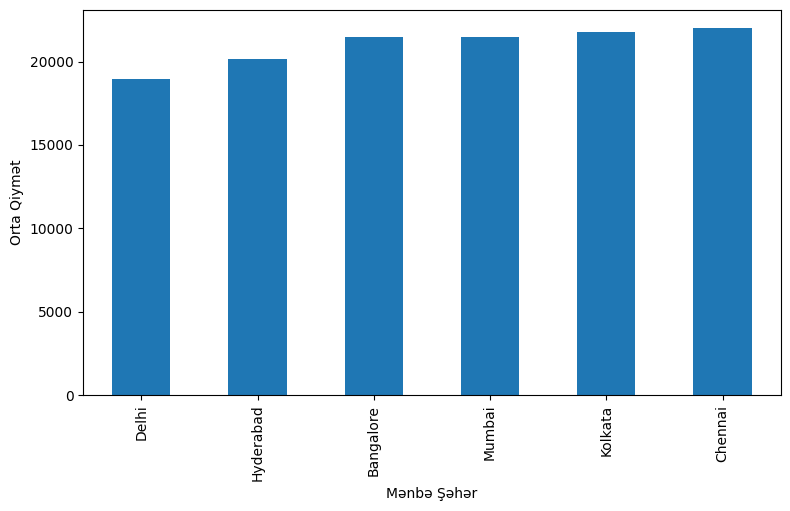

In [ ]:
plt.figure(figsize=(9, 5))
df.groupby('source_city')['price'].mean().sort_values().plot(kind='bar')
plt.xlabel('Mənbə Şəhər')
plt.ylabel('Orta Qiymət')
plt.show()

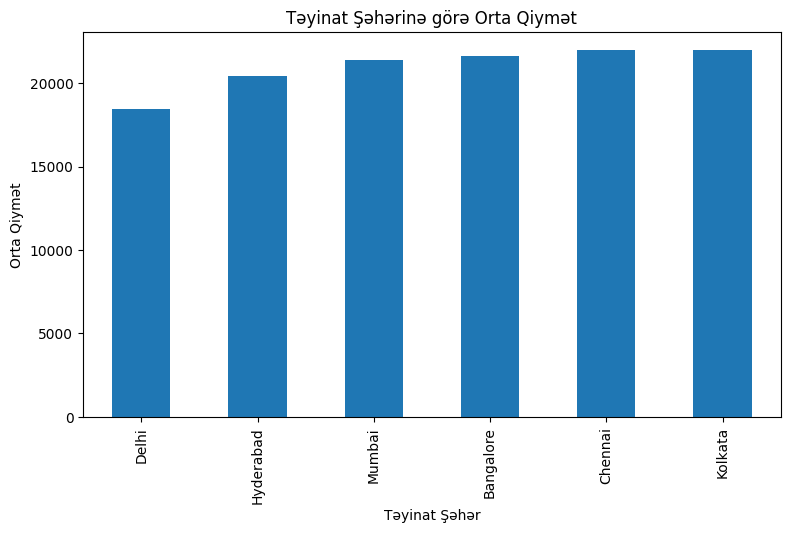

In [ ]:
plt.figure(figsize=(9, 5))
df.groupby('destination_city')['price'].mean().sort_values().plot(kind='bar')
plt.title('Təyinat Şəhərinə görə Orta Qiymət')
plt.xlabel('Təyinat Şəhər')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Biletlər uçuşdan cəmi 1 və ya 2 gün əvvəl alındıqda qiymət necə təsirlənir?

In [ ]:
df['buying_time'] = df['days_left'].apply(lambda x: '1-2 ' if x <= 2 else '3+ ')
early_vs_late_price = df.groupby('buying_time')['price'].mean()
early_vs_late_price

,price
buying_time,
1-2,27421.169326
3+,20757.498484


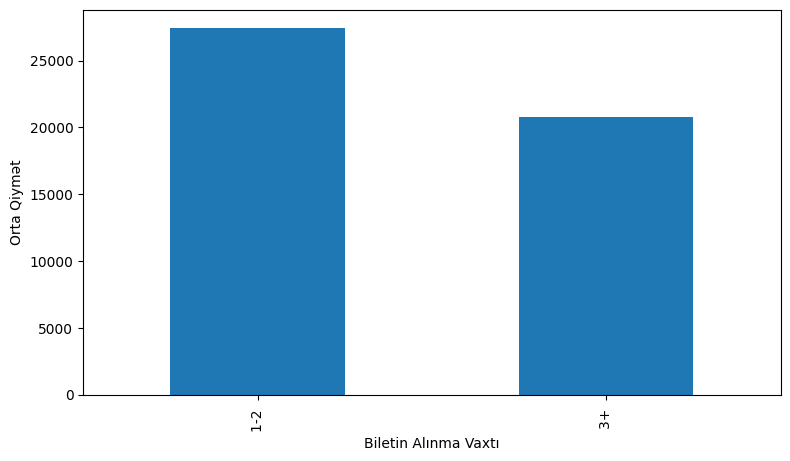

In [ ]:
plt.figure(figsize=(9, 5))
early_vs_late_price.plot(kind='bar')
plt.xlabel('Biletin Alınma Vaxtı')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Bilet qiyməti İqtisadiyyat və Biznes sinfi arasında necə dəyişir?

In [ ]:
class_prices = df.groupby('class')['price'].mean()
class_prices

,price
class,
Business,52540.081124
Economy,6572.342383


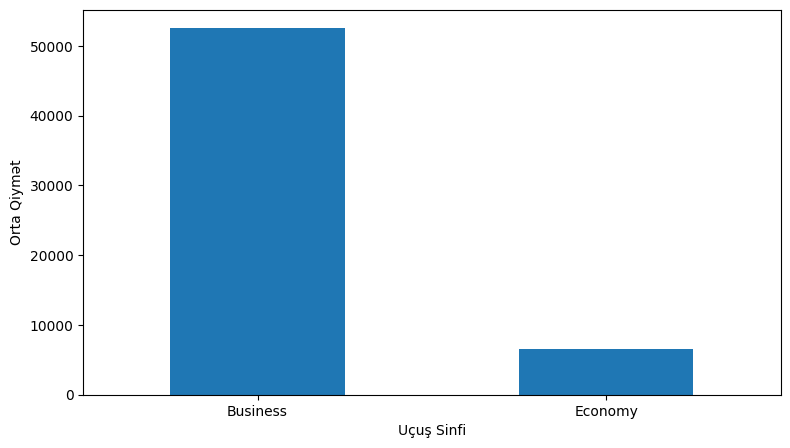

In [ ]:
plt.figure(figsize=(9, 5))
class_prices.plot(kind='bar')
plt.xlabel('Uçuş Sinfi')
plt.ylabel('Orta Qiymət')
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Datasetdəki uçuşların orta müddəti (duration) nə qədərdir və bu müddət sinflərə (Economy/Business) görə necə fərqlənir?


In [ ]:
average_duration=df['duration'].mean().round(2)
average_duration

np.float64(12.22)

In [ ]:
class_duration=df.groupby('class')['duration'].mean().round(2).reset_index()
class_duration

,class,duration
0,Business,13.70
1,Economy,11.55


<Figure size 900x500 with 0 Axes>

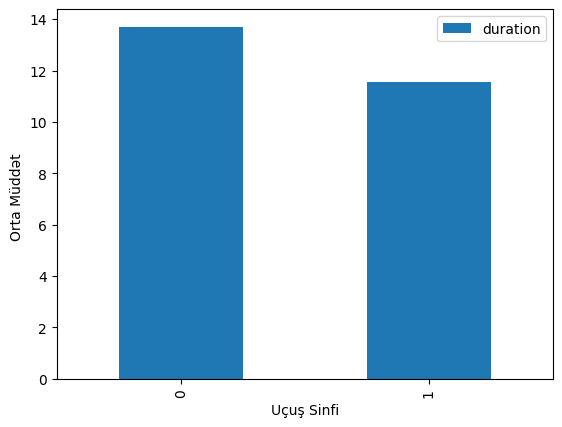

In [ ]:
plt.figure(figsize=(9, 5))
class_duration.plot(kind='bar')
plt.xlabel('Uçuş Sinfi')
plt.ylabel('Orta Müddət ')
plt.show()

In [ ]:
#Durak sayı (stops) qiymətə necə təsir edir? (Məsələn, zero, one, two_or_more duraklar üçün orta qiymətləri müqayisə edin.)

In [ ]:
stops_prices=df.groupby('stops')['price'].mean().round(2).reset_index()
stops_price

,stops,price
0,one,22900.99
1,two_or_more,14113.45
2,zero,9375.94


<Figure size 800x500 with 0 Axes>

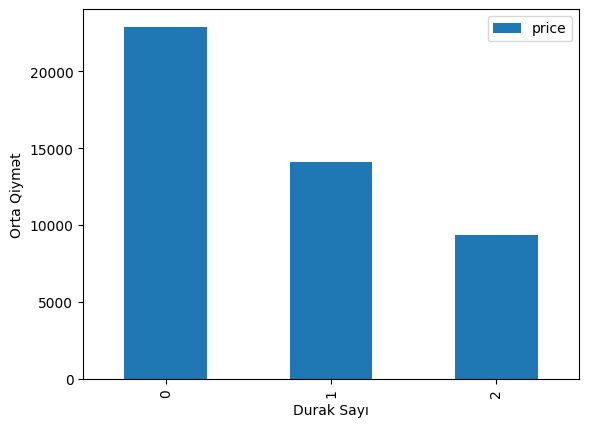

In [ ]:
plt.figure(figsize=(8, 5))
stops_prices.plot(kind='bar')
plt.xlabel('Durak Sayı')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Günlər qalmış (days_left) dəyişkəninə görə qiymətin paylanması necədir? (Məsələn, 1-10 gün, 11-20 gün və s. qruplar üzrə qrafik və ya orta qiymətlər.)

In [ ]:
df['days_left_group'] = pd.cut(df['days_left'], bins = [0, 10, 20, 30, 40, 50], labels=['1-10 ', '11-20', '21-30 ', '31-40 ', '41-50'])
days_price_groupby = df.groupby('days_left_group')['price'].mean()
days_price_groupby

/tmp/ipykernel_3300/2978393464.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  days_price_groupby = df.groupby('days_left_group')['price'].mean()


,price
days_left_group,
1-10,26082.751717
11-20,21260.475515
21-30,19625.787849
31-40,19393.765657
41-50,19108.742210


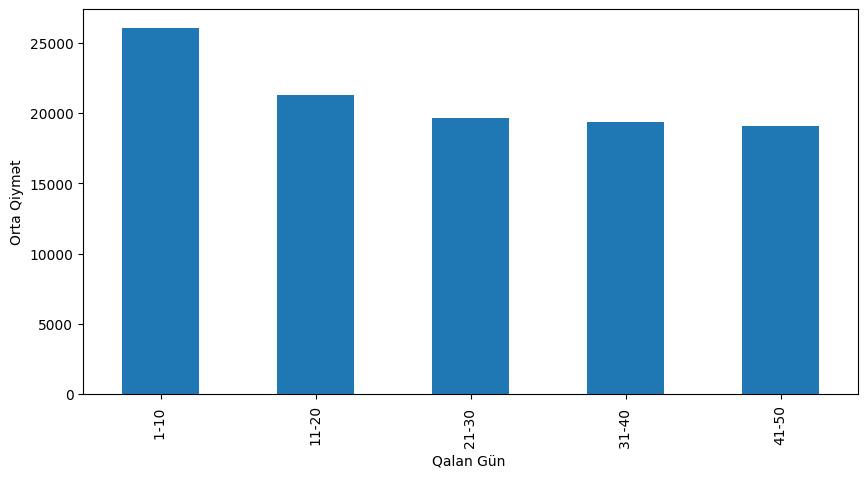

In [ ]:
plt.figure(figsize=(10, 5))
days_price_groupby.plot(kind='bar')
plt.xlabel('Qalan Gün ')
plt.ylabel('Orta Qiymət')
plt.show()

In [ ]:
#Hansı mənbə şəhərdən (source_city) ən çox uçuş var və onların orta qiyməti nə qədərdir?

In [ ]:
source_groupby = df.groupby('source_city').agg(
    flight_count=('price', 'count'),
    mean_price=('price', 'mean')).sort_values(by='flight_count', ascending=False)
source_groupby

,flight_count,mean_price
source_city,,
Delhi,61343,18951.326639
Mumbai,60896,21483.818839
Bangalore,52061,21469.460575
Kolkata,46347,21746.235679
Hyderabad,40806,20155.623879
Chennai,38700,21995.339871


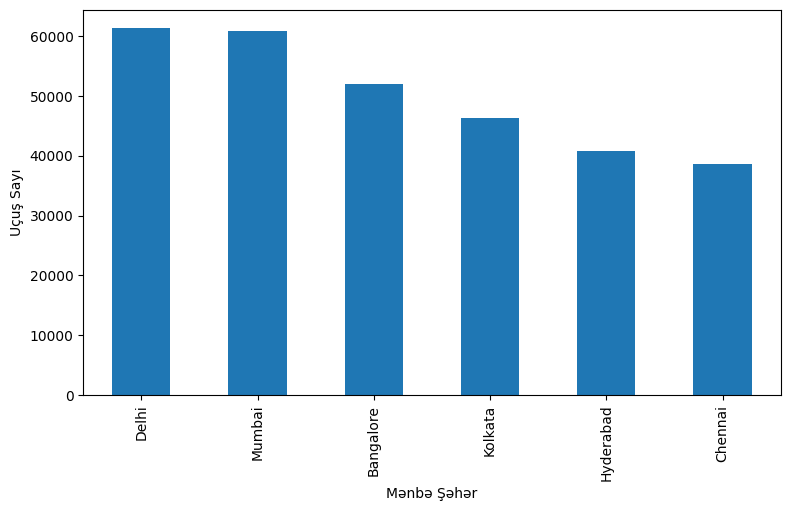

In [ ]:
plt.figure(figsize=(9, 5))
source_groupby['flight_count'].plot(kind='bar')
plt.xlabel('Mənbə Şəhər')
plt.ylabel('Uçuş Sayı')
plt.show()

In [ ]:
#Biznes sinfində uçuşların ümumi sayı və orta qiyməti İqtisadiyyat sinfi ilə müqayisədə necədir?

In [ ]:
class_comp=df.groupby('class').agg(flight_count=('class','count'),avg_price=('price','mean')).reset_index().sort_values(by='flight_count',ascending=False).round(2)
class_comp

,class,flight_count,avg_price
1,Economy,206666,6572.34
0,Business,93487,52540.08


In [ ]:
#Datasetdəki ən bahalı və ən ucuz uçuşlar hansı aviaşirkətlərə və şəhərlərə aiddir? (Ən azı 5 nümunə verin.)

In [ ]:
df.sort_values(by='price', ascending=False)[['airline', 'source_city', 'destination_city', 'class', 'price']].head()

,airline,source_city,destination_city,class,price
index,,,,,
261377,Vistara,Kolkata,Delhi,Business,123071
216096,Vistara,Delhi,Kolkata,Business,117307
215859,Vistara,Delhi,Kolkata,Business,116562
277345,Vistara,Hyderabad,Mumbai,Business,115211
270999,Vistara,Kolkata,Hyderabad,Business,114705


In [ ]:
df.sort_values(by='price', ascending=True)[['airline', 'source_city', 'destination_city', 'class', 'price']].head(5)

,airline,source_city,destination_city,class,price
index,,,,,
205100,GO_FIRST,Chennai,Hyderabad,Economy,1105
205112,Indigo,Chennai,Hyderabad,Economy,1105
205111,Indigo,Chennai,Hyderabad,Economy,1105
205110,Indigo,Chennai,Hyderabad,Economy,1105
205641,Indigo,Chennai,Hyderabad,Economy,1105
